In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

ROOT = Path("Bird Speciees Dataset")  # Change this if your dataset is elsewhere

paths = sorted(
    p for p in ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
)

if not paths:
    raise FileNotFoundError(f"No images found in {ROOT.resolve()}")

print(f"{len(paths)} images")

811 images


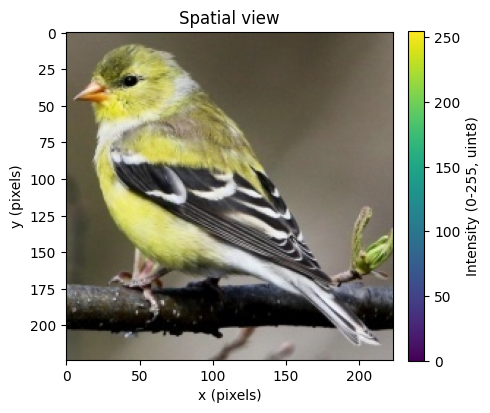

In [5]:
arr = np.asarray(Image.open(paths[0]).convert("RGB"))

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(arr)
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.set_title("Spatial view")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Intensity (0-255, uint8)")
plt.tight_layout()
plt.savefig("spatial_view.png", dpi=150)
plt.show()

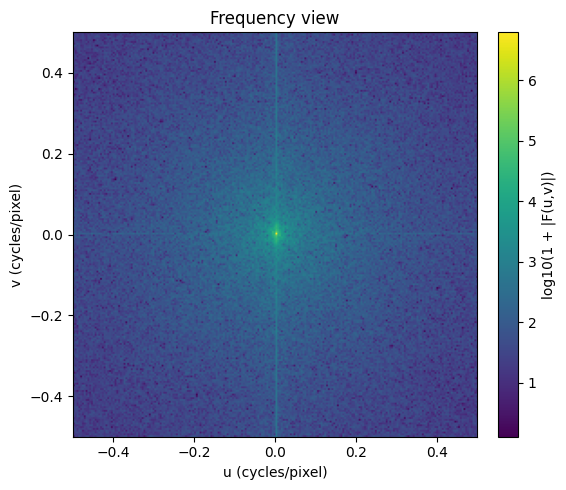

In [6]:
# Mean image across the dataset
mean_img = np.zeros((224, 224, 3), dtype=np.float64)
for p in paths:
    mean_img += np.asarray(Image.open(p).convert("RGB"), dtype=np.float64)
mean_img /= len(paths)
gray = mean_img.mean(axis=2)

# 2-D FFT
F = np.fft.fftshift(np.fft.fft2(gray))
mag = np.log10(1 + np.abs(F))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    mag,
    extent=[-0.5, 0.5, -0.5, 0.5],
    origin="lower",
    cmap="viridis",
)
ax.set_xlabel("u (cycles/pixel)")
ax.set_ylabel("v (cycles/pixel)")
ax.set_title("Frequency view")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("log10(1 + |F(u,v)|)")
plt.tight_layout()
plt.savefig("frequency_view.png", dpi=150)
plt.show()